# *Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cv2

from pathlib import Path
from PIL import Image, UnidentifiedImageError

import joblib

## ML imports

In [2]:
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (classification_report, f1_score, make_scorer, 
                                confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import (train_test_split, RandomizedSearchCV, 
                                        PredefinedSplit)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC, SVC

from xgboost import XGBClassifier

from skimage import exposure
from skimage.color import rgb2gray
from skimage.feature import hog


## Utility

In [3]:
import util

import importlib
importlib.reload(util)

<module 'util' from 'c:\\Users\\Deomary\\Projects\\AI201\\mini-project\\util.py'>

# Pull Images

In [4]:
image_path = Path.cwd() / "GTSRB_Final_Training_Images/GTSRB/Final_Training/Images"
image_folders = []
for folder in image_path.iterdir():
    image_folders.append(folder)

print(f'There are {len(image_folders)} folder(s) in Directory: {image_path.absolute().__str__()}')

There are 43 folder(s) in Directory: c:\Users\Deomary\Projects\AI201\mini-project\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images


In [5]:
meta_csv_list = util.get_meta_data(image_path)
meta_df = pd.concat(meta_csv_list).reset_index(drop=True)
meta_df

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000_00000.ppm,29,30,5,6,24,25,0
1,00000_00001.ppm,30,30,5,5,25,25,0
2,00000_00002.ppm,30,30,5,5,25,25,0
3,00000_00003.ppm,31,31,5,5,26,26,0
4,00000_00004.ppm,30,32,5,6,25,26,0
...,...,...,...,...,...,...,...,...
39204,00007_00025.ppm,52,56,5,6,47,51,42
39205,00007_00026.ppm,56,58,5,5,51,53,42
39206,00007_00027.ppm,58,62,5,6,53,57,42
39207,00007_00028.ppm,63,69,5,7,58,63,42


In [6]:
shapes = []
folder_count = {'label': [], 'count': []}

for folder in image_folders:
    n_per_folder = 0
    for image in folder.iterdir():
        try:
            n_per_folder += 1
            image = Image.open(image)
            image = np.array(image)
            shapes.append(image.shape)
        except UnidentifiedImageError:
            print(f'Skipped {image.name}')
            
    folder_count['label'].append(folder.name)
    folder_count['count'].append(n_per_folder)


Skipped GT-00000.csv
Skipped GT-00001.csv
Skipped GT-00002.csv
Skipped GT-00003.csv
Skipped GT-00004.csv
Skipped GT-00005.csv
Skipped GT-00006.csv
Skipped GT-00007.csv
Skipped GT-00008.csv
Skipped GT-00009.csv
Skipped GT-00010.csv
Skipped GT-00011.csv
Skipped GT-00012.csv
Skipped GT-00013.csv
Skipped GT-00014.csv
Skipped GT-00015.csv
Skipped GT-00016.csv
Skipped GT-00017.csv
Skipped GT-00018.csv
Skipped GT-00019.csv
Skipped GT-00020.csv
Skipped GT-00021.csv
Skipped GT-00022.csv
Skipped GT-00023.csv
Skipped GT-00024.csv
Skipped GT-00025.csv
Skipped GT-00026.csv
Skipped GT-00027.csv
Skipped GT-00028.csv
Skipped GT-00029.csv
Skipped GT-00030.csv
Skipped GT-00031.csv
Skipped GT-00032.csv
Skipped GT-00033.csv
Skipped GT-00034.csv
Skipped GT-00035.csv
Skipped GT-00036.csv
Skipped GT-00037.csv
Skipped GT-00038.csv
Skipped GT-00039.csv
Skipped GT-00040.csv
Skipped GT-00041.csv
Skipped GT-00042.csv


## Image Distribution per Label

In [7]:
folder_count_df = pd.DataFrame(folder_count)
folder_count_df

,label,count
0,00000,211
1,00001,2221
2,00002,2251
3,00003,1411
4,00004,1981
5,00005,1861
6,00006,421
7,00007,1441
8,00008,1411
9,00009,1471


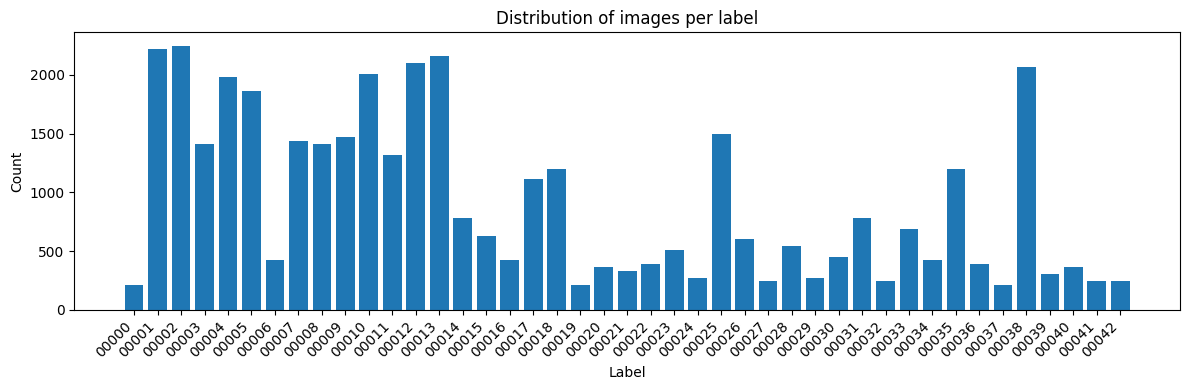

In [8]:
plt.figure(figsize=(12, 4))
plt.bar(folder_count_df['label'], folder_count_df['count'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of images per label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

In [9]:
print(f"There are {folder_count_df.shape[0]} folder(s) in Directory: {image_path.absolute().__str__()}")
print(f"There are {folder_count_df['count'].sum()} image(s)")
print(f"Minimum no. of images per folder: {folder_count_df['count'].min()}")
print(f"Maximum no. of images per folder: {folder_count_df['count'].max()}")
print(f"Average no. of images per folder: {folder_count_df['count'].mean():.0f}")
print(f"Median no. of images per folder: {np.median(folder_count_df['count']):.0f}")

There are 43 folder(s) in Directory: c:\Users\Deomary\Projects\AI201\mini-project\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images
There are 39252 image(s)
Minimum no. of images per folder: 211
Maximum no. of images per folder: 2251
Average no. of images per folder: 913
Median no. of images per folder: 601


## Image Dimension Statistics

In [10]:
shape_df = pd.DataFrame(shapes, columns=['height', 'width', 'rgb'])
shape_df.describe()

,height,width,rgb
count,39209.000000,39209.000000,39209.0
mean,50.328930,50.835880,3.0
std,23.115423,24.306933,0.0
min,25.000000,25.000000,3.0
25%,35.000000,35.000000,3.0
50%,43.000000,43.000000,3.0
75%,58.000000,58.000000,3.0
max,225.000000,243.000000,3.0


In [11]:
shape_df = pd.DataFrame(shapes, columns=['height', 'width', 'rgb number'])
print(f"Images has a max height of {shape_df['height'].max()}")
print(f"Images has a avg height of {shape_df['height'].mean()}")
print(f"Images has a min height of {shape_df['height'].min()}")
print()
print(f"Images has a max width of {shape_df['width'].max()}")
print(f"Images has a avg width of {shape_df['width'].mean()}")
print(f"Images has a min width of {shape_df['width'].min()}")


Images has a max height of 225
Images has a avg height of 50.328929582493814
Images has a min height of 25

Images has a max width of 243
Images has a avg width of 50.83587951745773
Images has a min width of 25


## Sample Images

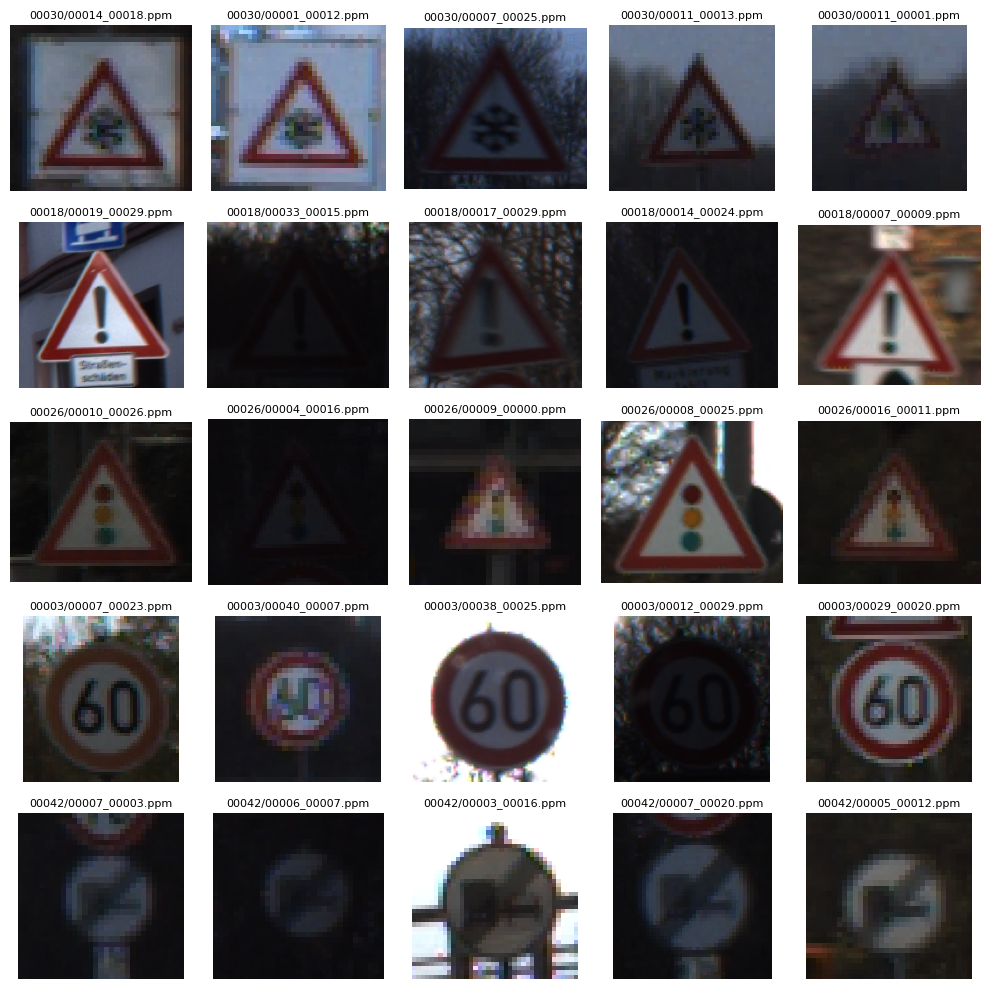

In [12]:
n_folders = 5
n_images = 5

rng = np.random.default_rng(seed=42)
random_folders = rng.choice(image_folders, n_folders, replace=False)
sample_images = {}

for folder in random_folders:
    random_ppms = rng.choice(list(folder.iterdir()), n_images, replace=False)
    for ppm in random_ppms:
        name = f'{folder.name}/{ppm.name}'
        img = Image.open(ppm)
        sample_images[name] = img

names = list(sample_images.keys())

fig, axes = plt.subplots(n_folders, n_images, figsize=(10, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(sample_images[names[i]], cmap='gray') 
    ax.set_title(f'{names[i]}', fontsize=8)
    ax.axis('off') 

plt.tight_layout()
plt.show()

## Sample of an Image for all Labels

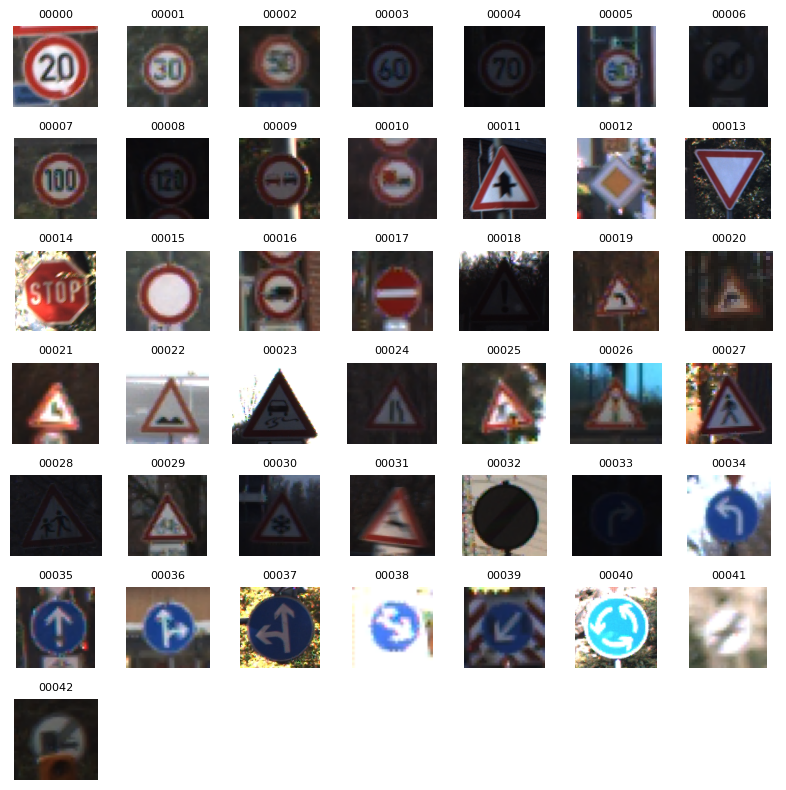

In [13]:
rng = np.random.default_rng(seed=42)
sample_images = {}

for folder in image_folders:
    random_ppms = rng.choice(list(folder.iterdir()), 1, replace=False)
    for ppm in random_ppms:
        name = f'{folder.name}'
        img = Image.open(ppm)
        sample_images[name] = img

names = list(sample_images.keys())

fig, axes = plt.subplots(7, 7, figsize=(8, 8))
axes = axes.flatten()
for i, ax in enumerate(axes):
    try:
        ax.imshow(sample_images[names[i]], cmap='gray')
        ax.set_title(f'{names[i]}', fontsize=8)
    except:
        pass
    ax.axis('off') 

plt.tight_layout()
plt.show()

Sample numpy array of image:
[[[27 22 20]
  [27 23 22]
  [25 22 21]
  ...
  [25 22 20]
  [26 23 21]
  [27 24 21]]

 [[29 24 22]
  [26 23 21]
  [26 25 23]
  ...
  [26 23 21]
  [25 23 21]
  [27 25 23]]

 [[28 23 21]
  [23 21 19]
  [25 26 24]
  ...
  [25 22 20]
  [26 24 22]
  [27 25 22]]

 ...

 [[24 23 22]
  [25 26 25]
  [38 42 37]
  ...
  [33 29 23]
  [28 26 20]
  [32 31 27]]

 [[22 22 20]
  [27 28 26]
  [32 35 30]
  ...
  [31 26 20]
  [27 25 19]
  [29 30 24]]

 [[22 21 18]
  [28 27 23]
  [29 28 23]
  ...
  [28 24 19]
  [29 27 20]
  [30 30 23]]]
This image has shape: (36, 37, 3)


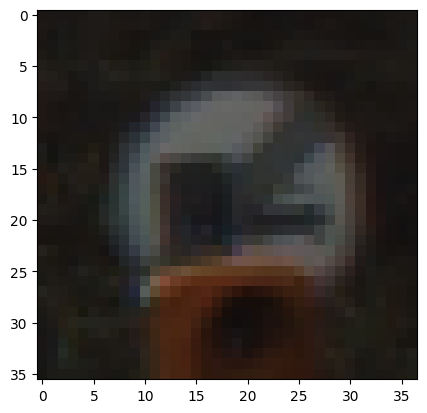

In [14]:
sample_images[0] = np.array(img)
plt.imshow(sample_images[0])
print('Sample numpy array of image:')
print(sample_images[0])
print(f'This image has shape: {sample_images[0].shape}')

# Data Preprocessing

[[[0.3137255  0.30588236 0.29411766]
  [0.30980393 0.30588236 0.29411766]
  [0.30980393 0.3019608  0.2901961 ]
  ...
  [0.2627451  0.26666668 0.25490198]
  [0.25882354 0.2627451  0.25882354]
  [0.25882354 0.2627451  0.25882354]]

 [[0.31764707 0.30980393 0.3019608 ]
  [0.31764707 0.30980393 0.29803923]
  [0.30980393 0.30588236 0.29803923]
  ...
  [0.27058825 0.27450982 0.26666668]
  [0.26666668 0.27450982 0.26666668]
  [0.26666668 0.27450982 0.27058825]]

 [[0.32941177 0.32156864 0.3137255 ]
  [0.3254902  0.31764707 0.3137255 ]
  [0.32156864 0.3137255  0.30980393]
  ...
  [0.28627452 0.29411766 0.28627452]
  [0.2901961  0.29803923 0.29411766]
  [0.2901961  0.29803923 0.29411766]]

 ...

 [[0.37254903 0.35686275 0.34901962]
  [0.3764706  0.3647059  0.34901962]
  [0.39607844 0.3764706  0.35686275]
  ...
  [0.38431373 0.41568628 0.4       ]
  [0.3764706  0.40392157 0.3764706 ]
  [0.37254903 0.4        0.36862746]]

 [[0.34901962 0.3372549  0.3372549 ]
  [0.36078432 0.34901962 0.34117648]


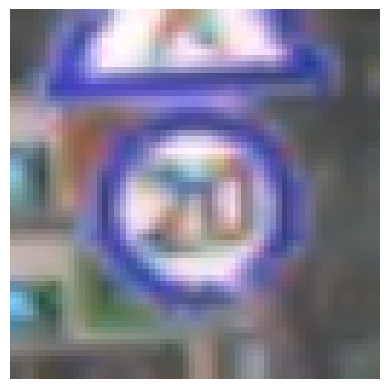

In [15]:
sample_preprocessed_image = util.preprocess_image(list(image_folders[0].iterdir())[0])
print(sample_preprocessed_image)
plt.imshow(sample_preprocessed_image)
plt.axis('off')

print(sample_preprocessed_image.shape)

In [16]:
X, y = util.load_data_from_folders(image_path, None, padding=2)
print('Done preprocessing!')

labels: 01 label [00:00, ?1 label/s]

Done preprocessing!


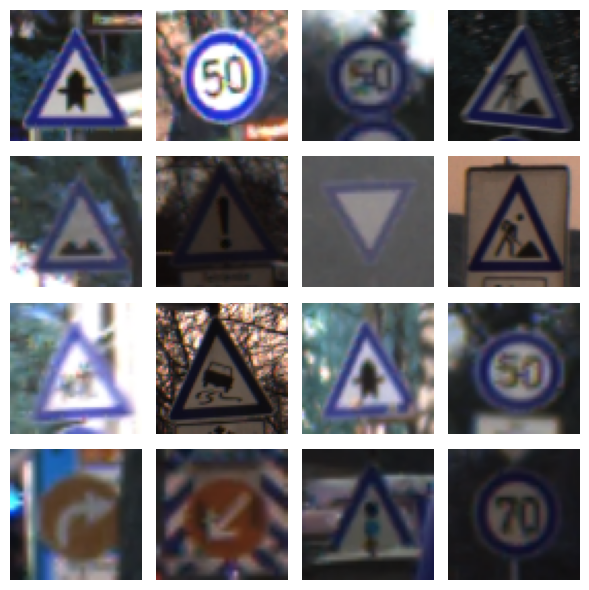

In [17]:
rng = np.random.default_rng(seed=42)
random_int = rng.choice(np.arange(len(y)), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(X[random_int[i]], cmap='gray')
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [18]:
np.savez_compressed("image_data.npz", X=X, y=y)
print('Done Saving!')

Done Saving!


# Baseline Models

## *Split Model

In [7]:
data = np.load('image_data.npz')
X = data['X']
y = data['y']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (39252, 64, 64, 3)
y shape: (39252,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print('Train, Test, and Validation counts')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'y_val shape: {y_val.shape}')

Train, Test, and Validation counts
X_train shape: (24728, 64, 64, 3)
X_test shape: (11776, 64, 64, 3)
X_val shape: (2748, 64, 64, 3)
y_train shape: (24728,)
y_test shape: (11776,)
y_val shape: (2748,)


In [9]:
df_label_dist = pd.concat(
    [
        pd.DataFrame(y).value_counts(normalize=True).to_frame()
        for y in [y_train, y_test, y_val]
        # y_train.value_counts(normalize=True).to_frame(),
        # y_test.value_counts(normalize=True).to_frame(),
        # y_val.value_counts(normalize=True).to_frame()
    ],
    axis=1
)
df_label_dist.columns = ['Train Dist.', 'Test Dist.', 'Val Dist.']
df_label_dist['Dist. Error %'] = np.abs(
    100*(df_label_dist['Train Dist.'] - df_label_dist['Test Dist.'])/df_label_dist['Train Dist.']
)
df_label_dist.sort_values('Dist. Error %', ascending=False)

,Train Dist.,Test Dist.,Val Dist.,Dist. Error %
0,,,,
21,0.008452,0.008407,0.008370,0.532752
24,0.006915,0.006878,0.006914,0.532752
32,0.006147,0.006114,0.006186,0.532752
27,0.006147,0.006114,0.006186,0.532752
39,0.007684,0.007643,0.007642,0.532752
29,0.006915,0.006878,0.006914,0.532752
41,0.006147,0.006114,0.006186,0.532752
42,0.006147,0.006114,0.006186,0.532752
0,0.005379,0.005350,0.005459,0.532752


In [10]:
X_combined = np.vstack((X_train, X_val))
y_combined = np.concatenate((y_train, y_val))

val_fold = np.concatenate((
    -1 * np.ones(len(X_train), dtype=int),
    np.zeros(len(X_val), dtype=int)
))

predefined_split = PredefinedSplit(test_fold=val_fold)

### Hyperparameter Tuned SGD Classifier

# PCA(ALL)

In [21]:
X_train_flat = util.preprocess_flatten(X_train)
X_combined_flat = util.preprocess_flatten(X_combined)
X_test_flat = util.preprocess_flatten(X_test)

In [22]:
ss = StandardScaler()
X_train_flat = ss.fit_transform(X_train_flat)
X_combined_flat = ss.transform(X_combined_flat)
X_test_flat = ss.transform(X_test_flat)

In [34]:
pca = PCA(n_components=0.95)
pca.fit(X_train_flat)
print(pca.n_components_)

126


In [35]:
X_train_pcaall = pca.transform(X_train_flat)
X_combined_pcaall = pca.transform(X_combined_flat)
X_test_pcaall = pca.transform(X_test_flat)

In [57]:
np.savez_compressed("XPCAALL.npz", 
                    X_combined_pcaall=X_combined_pcaall, 
                    X_test_pcaall=X_test_pcaall,
                    X_train_pcaall=X_train_pcaall)

In [82]:
pcadata = np.load('XPCAALL.npz')
X_train_pcaall = pcadata['X_train_pcaall']
X_combined_pcaall = pcadata['X_combined_pcaall']
X_test_pcaall = pcadata['X_test_pcaall']

## PCA(ALL) SGD

In [92]:
param_grid = {
    'sgdclassifier__loss': ['hinge', 'log_loss', 'modified_huber'],  # SVM, logistic, robust
    'sgdclassifier__alpha': [1e-4, 1e-3, 1e-2],  # Regularization strength
    'sgdclassifier__penalty': ['l2', 'l1', 'elasticnet'],  # Regularization type
    'sgdclassifier__tol': [1e-3, 1e-4],  # Convergence threshold
    'sgdclassifier__learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'sgdclassifier__eta0': [0.001, 0.01, 0.1],  # Initial learning rate
}

model_sgd_pcaall_ht, clf_report_sgd_pcaall_ht = util.search(
    SGDClassifier(random_state=42, n_jobs=-1, early_stopping=True),
    X_combined_pcaall, y_combined,
    X_test_pcaall, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

# 25.4 s

In [ ]:
pd.DataFrame(clf_report_sgd_pcaall_ht).T
# 0.8871

,precision,recall,f1-score,support
0,0.851852,0.730159,0.786325,63.000000
1,0.852761,0.833583,0.843063,667.000000
2,0.843465,0.821006,0.832084,676.000000
3,0.812195,0.785377,0.798561,424.000000
4,0.797546,0.873950,0.834002,595.000000
5,0.802817,0.713775,0.755682,559.000000
6,0.876812,0.960317,0.916667,126.000000
7,0.875661,0.764434,0.816276,433.000000
8,0.746362,0.846698,0.793370,424.000000
9,0.966265,0.907240,0.935823,442.000000


## PCA(ALL) MLP

In [ ]:
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [
        (64,), (128,), (128, 64), (256, 128)
    ],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [1e-4, 1e-3, 1e-2],
    'mlpclassifier__learning_rate_init': [0.001, 0.01, 0.1],
    'mlpclassifier__early_stopping': [True]
}

model_mlp_pcaall_ht, clf_report_mlp_pcaall_ht = util.search(
    MLPClassifier(random_state=42),
    X_combined_pcaall, y_combined,
    X_test_pcaall, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

# 2m 15.9s

In [ ]:
pd.DataFrame(clf_report_mlp_pcaall_ht).T
# 0.9665

,precision,recall,f1-score,support
0,1.000000,0.873016,0.932203,63.000000
1,0.964126,0.967016,0.965569,667.000000
2,0.961310,0.955621,0.958457,676.000000
3,0.933492,0.926887,0.930178,424.000000
4,0.963025,0.963025,0.963025,595.000000
5,0.929947,0.949911,0.939823,559.000000
6,0.976562,0.992063,0.984252,126.000000
7,0.961995,0.935335,0.948478,433.000000
8,0.918919,0.962264,0.940092,424.000000
9,0.972851,0.972851,0.972851,442.000000


## PCA(ALL) SVM

In [ ]:
param_grid = {
    'svc__kernel': ['rbf'],
    'svc__C': [1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

model_svc_pcaall_ht, clf_report_svc_pcaall_ht = util.search(
    SVC(random_state=42),
    X_combined_pcaall, y_combined,
    X_test_pcaall, y_test,
    param_grid=param_grid,
    n_iter=12,
    cv=predefined_split
)
#  9m 59.2s

In [ ]:
pd.DataFrame(clf_report_svc_pcaall_ht).T
# 0.9538

,precision,recall,f1-score,support
0,1.000000,0.777778,0.875000,63.000000
1,0.885089,0.970015,0.925608,667.000000
2,0.950365,0.963018,0.956650,676.000000
3,0.906760,0.917453,0.912075,424.000000
4,0.939245,0.961345,0.950166,595.000000
5,0.913043,0.939177,0.925926,559.000000
6,1.000000,1.000000,1.000000,126.000000
7,0.954545,0.921478,0.937720,433.000000
8,0.942446,0.926887,0.934602,424.000000
9,0.974178,0.938914,0.956221,442.000000


## PCA(ALL) XGBoost

In [ ]:
param_grid = {
    'xgbclassifier__n_estimators': [100, 150, 200],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0]
}

model_xgb_pcaall_ht, clf_report_xgb_pcaall_ht = util.search(
    XGBClassifier(
        objective='multi:softmax',
        num_class=43,
        eval_metric='mlogloss',
        use_label_encoder=False,
        verbosity=0,
        n_jobs=-1,
        random_state=42
    ),
    X_combined_pcaall, y_combined,
    X_test_pcaall, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)
# 12 55.1s

In [102]:
pd.DataFrame(clf_report_xgb_pcaall_ht).T
# 0.9229

,precision,recall,f1-score,support
0,1.000000,0.571429,0.727273,63.000000
1,0.872045,0.940030,0.904762,667.000000
2,0.860111,0.918639,0.888412,676.000000
3,0.794643,0.839623,0.816514,424.000000
4,0.904040,0.902521,0.903280,595.000000
5,0.767442,0.885510,0.822259,559.000000
6,0.921875,0.936508,0.929134,126.000000
7,0.890443,0.882217,0.886311,433.000000
8,0.890951,0.905660,0.898246,424.000000
9,0.970183,0.957014,0.963554,442.000000


# PCA(HOG)

In [5]:
img = cv2.imread(image_path/'00000'/'00000_00000.ppm')
img_resized = cv2.resize(img, (64, 64))
gray = rgb2gray(img_resized)
gray

array([[0.30670078, 0.30586745, 0.30277922, ..., 0.2649851 , 0.26162902,
        0.26162902],
       [0.3109051 , 0.31062235, 0.3061502 , ..., 0.27311098, 0.27227765,
        0.27256039],
       [0.3226698 , 0.31903098, 0.31510941, ..., 0.29188549, 0.2960898 ,
        0.2960898 ],
       ...,
       [0.35963059, 0.3660749 , 0.37922353, ..., 0.40788863, 0.39610902,
        0.39190471],
       [0.3397549 , 0.35095412, 0.37558471, ..., 0.39053569, 0.37987216,
        0.37650118],
       [0.33219451, 0.3445098 , 0.37475137, ..., 0.38269255, 0.37511725,
        0.37174627]], shape=(64, 64))

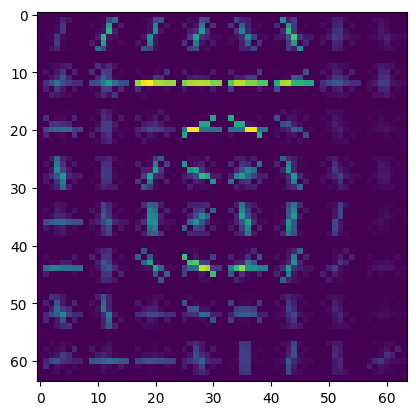

In [11]:
features, hog_image = hog(
    rgb2gray(X[0]),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True,  
    feature_vector=True,
)

plt.imshow(hog_image)

In [23]:
X_train_hog = util.generate_hog_features(X_train.reshape(X_train.shape[0], 64, 64, 3))
X_combined_hog = util.generate_hog_features(X_combined.reshape(X_combined.shape[0], 64, 64, 3))
X_test_hog = util.generate_hog_features(X_test.reshape(X_test.shape[0], 64, 64, 3))


In [24]:
ss_hog = StandardScaler()
X_train_hog = ss_hog.fit_transform(X_train_hog)
X_combined_hog = ss_hog.transform(X_combined_hog)
X_test_hog = ss_hog.transform(X_test_hog)

In [36]:
print(f'Total features: {X_test_hog.shape[1]}')
pca_hog = PCA(n_components=0.95)
pca_hog.fit_transform(X_train_hog)
print(pca_hog.n_components_)

Total features: 1764
497


In [ ]:
# X_train_allhog = np.hstack([X_train_hog, X_train.to_numpy()])
# X_combined_allhog = np.hstack([X_combined_hog, X_combined])
# X_test_allhog = np.hstack([X_test_hog, X_test.to_numpy()])

# print(f'Total features: {X_train_allhog.shape[1]}')

# pca_hog = PCA(n_components=0.95)
# pca_hog.fit(X_train_hog)

# print(pca_hog.n_components_)

479


In [16]:
X_train_hogpca = pca_hog.transform(X_train_hog)
X_combined_hogpca = pca_hog.transform(X_combined_hog)
X_test_hogpca = pca_hog.transform(X_test_hog)

## PCA(HOG) SGD

In [17]:
param_grid = {
    'sgdclassifier__loss': ['hinge', 'log_loss', 'modified_huber'],  # SVM, logistic, robust
    'sgdclassifier__alpha': [1e-4, 1e-3, 1e-2],  # Regularization strength
    'sgdclassifier__penalty': ['l2', 'l1', 'elasticnet'],  # Regularization type
    'sgdclassifier__tol': [1e-3, 1e-4],  # Convergence threshold
    'sgdclassifier__learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'sgdclassifier__eta0': [0.001, 0.01, 0.1],  # Initial learning rate
}

model_sgd_hogpca_ht, clf_report_sgd_hogpca_ht = util.search(
    SGDClassifier(random_state=42, n_jobs=-1, early_stopping=True),
    X_combined_hogpca, y_combined,
    X_test_hogpca, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_sgd_hogpca_ht).T
# 0.9601

,precision,recall,f1-score,support
0,1.000000,0.888889,0.941176,63.000000
1,0.918033,0.923538,0.920777,667.000000
2,0.861968,0.868343,0.865144,676.000000
3,0.922897,0.931604,0.927230,424.000000
4,0.963025,0.963025,0.963025,595.000000
5,0.857664,0.840787,0.849142,559.000000
6,1.000000,0.992063,0.996016,126.000000
7,0.930337,0.956120,0.943052,433.000000
8,0.918981,0.936321,0.927570,424.000000
9,0.975281,0.981900,0.978579,442.000000


## PCA(HOG) MLP

In [19]:
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [
        (64,), (128,), (128, 64), (256, 128)
    ],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [1e-4, 1e-3, 1e-2],
    'mlpclassifier__learning_rate_init': [0.001, 0.01, 0.1],
    'mlpclassifier__early_stopping': [True]
}

model_mlp_hogpca_ht, clf_report_mlp_hogpca_ht = util.search(
    MLPClassifier(random_state=42),
    X_combined_hogpca, y_combined,
    X_test_hogpca, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_mlp_hogpca_ht).T
# 0.9699

,precision,recall,f1-score,support
0,1.000000,0.936508,0.967213,63.000000
1,0.940209,0.943028,0.941617,667.000000
2,0.907216,0.911243,0.909225,676.000000
3,0.948598,0.957547,0.953052,424.000000
4,0.973064,0.971429,0.972246,595.000000
5,0.898711,0.872987,0.885662,559.000000
6,1.000000,1.000000,1.000000,126.000000
7,0.947727,0.963048,0.955326,433.000000
8,0.933941,0.966981,0.950174,424.000000
9,0.988558,0.977376,0.982935,442.000000


## PCA(HOG) SVM

In [21]:
param_grid = {
    'svc__kernel': ['rbf'],
    'svc__C': [1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

model_svc_hogpca_ht, clf_report_svc_hogpca_ht = util.search(
    SVC(random_state=42),
    X_combined_hogpca, y_combined,
    X_test_hogpca, y_test,
    param_grid=param_grid,
    n_iter=12,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_svc_hogpca_ht).T
# 0.9786

,precision,recall,f1-score,support
0,1.000000,0.952381,0.975610,63.000000
1,0.944363,0.967016,0.955556,667.000000
2,0.920821,0.928994,0.924890,676.000000
3,0.968523,0.943396,0.955795,424.000000
4,0.988136,0.979832,0.983966,595.000000
5,0.910072,0.905188,0.907623,559.000000
6,1.000000,1.000000,1.000000,126.000000
7,0.972028,0.963048,0.967517,433.000000
8,0.955607,0.964623,0.960094,424.000000
9,0.993228,0.995475,0.994350,442.000000


## PCA(HOG) XGBoost

In [24]:
param_grid = {
    'xgbclassifier__n_estimators': [100, 150, 200],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0]
}

model_xgb_hogpca_ht, clf_report_xgb_hogpca_ht = util.search(
    XGBClassifier(
        objective='multi:softmax',
        num_class=43,
        eval_metric='mlogloss',
        use_label_encoder=False,
        verbosity=0,
        n_jobs=-1,
        random_state=42
    ),
    X_combined_hogpca, y_combined,
    X_test_hogpca, y_test,
    param_grid=param_grid,
    n_iter=10,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_xgb_hogpca_ht).T
# 0.9418

,precision,recall,f1-score,support
0,1.000000,0.682540,0.811321,63.000000
1,0.891496,0.911544,0.901408,667.000000
2,0.844286,0.874260,0.859012,676.000000
3,0.910448,0.863208,0.886199,424.000000
4,0.972461,0.949580,0.960884,595.000000
5,0.814558,0.840787,0.827465,559.000000
6,0.984127,0.984127,0.984127,126.000000
7,0.947005,0.949192,0.948097,433.000000
8,0.920561,0.929245,0.924883,424.000000
9,0.965831,0.959276,0.962543,442.000000


# PCA(LBP)

In [26]:
X_train_lbp = util.generate_lbp_features(X_train.reshape(X_train.shape[0], 64, 64, 3))
X_combined_lbp = util.generate_lbp_features(X_combined.reshape(X_combined.shape[0], 64, 64, 3))
X_test_lbp = util.generate_lbp_features(X_test.reshape(X_test.shape[0], 64, 64, 3))

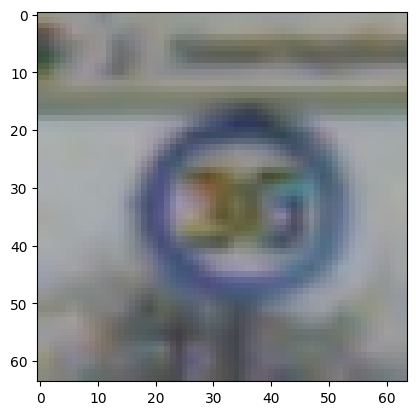

In [269]:
plt.imshow(X_train[0])

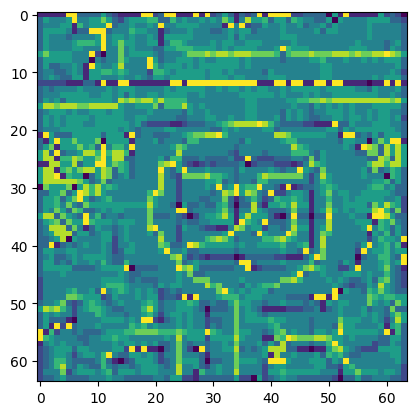

In [270]:
plt.imshow(X_train_lbp[0])

In [27]:
X_train_lbp = util.generate_lbp_features2(X_train_lbp)
X_combined_lbp = util.generate_lbp_features2(X_combined_lbp)
X_test_lbp = util.generate_lbp_features2(X_test_lbp)

In [28]:
X_train_lbp = util.preprocess_flatten(X_train_lbp)
X_combined_lbp = util.preprocess_flatten(X_combined_lbp)
X_test_lbp = util.preprocess_flatten(X_test_lbp)

In [29]:
ss_lbp = StandardScaler()
X_train_lbp = ss_lbp.fit_transform(X_train_lbp)
X_combined_lbp = ss_lbp.transform(X_combined_lbp)
X_test_lbp = ss_lbp.transform(X_test_lbp)

In [37]:
print(f'Total features: {X_test_lbp.shape[1]}')
pca_lbp = PCA(n_components=0.95)
pca_lbp.fit(X_train_lbp)
print(pca_lbp.n_components_)
# 3474

Total features: 640
479


In [291]:
X_train_lbppca = pca_lbp.transform(X_train_lbp)
X_combined_lbppca = pca_lbp.transform(X_combined_lbp)
X_test_lbppca = pca_lbp.transform(X_test_lbp)

## PCA(LBP) SGD

In [292]:
param_grid = {
    'sgdclassifier__loss': ['hinge', 'log_loss', 'modified_huber'],  # SVM, logistic, robust
    'sgdclassifier__alpha': [1e-4, 1e-3, 1e-2],  # Regularization strength
    'sgdclassifier__penalty': ['l2', 'l1', 'elasticnet'],  # Regularization type
    'sgdclassifier__tol': [1e-3, 1e-4],  # Convergence threshold
    'sgdclassifier__learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'sgdclassifier__eta0': [0.001, 0.01, 0.1],  # Initial learning rate
}

model_sgd_lbppca_ht, clf_report_sgd_lbppca_ht = util.search(
    SGDClassifier(random_state=42, n_jobs=-1, early_stopping=True),
    X_combined_lbppca, y_combined,
    X_test_lbppca, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_sgd_lbppca_ht).T
# 0.8383152173913043

,precision,recall,f1-score,support
0,0.882353,0.476190,0.618557,63.000000
1,0.686695,0.719640,0.702782,667.000000
2,0.697977,0.714497,0.706140,676.000000
3,0.740831,0.714623,0.727491,424.000000
4,0.786078,0.778151,0.782095,595.000000
5,0.681901,0.667263,0.674503,559.000000
6,0.944444,0.944444,0.944444,126.000000
7,0.768750,0.852194,0.808324,433.000000
8,0.733781,0.773585,0.753157,424.000000
9,0.831776,0.805430,0.818391,442.000000


## PCA(LBP) MLP

In [295]:
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [
        (64,), (128,), (128, 64), (256, 128)
    ],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [1e-4, 1e-3, 1e-2],
    'mlpclassifier__learning_rate_init': [0.001, 0.01, 0.1],
    'mlpclassifier__early_stopping': [True]
}

model_mlp_lbppca_ht, clf_report_mlp_lbppca_ht = util.search(
    MLPClassifier(random_state=42),
    X_combined_lbppca, y_combined,
    X_test_lbppca, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_mlp_lbppca_ht).T
# 0.8475713315217391

,precision,recall,f1-score,support
0,0.837209,0.571429,0.679245,63.000000
1,0.724928,0.758621,0.741392,667.000000
2,0.699721,0.741124,0.719828,676.000000
3,0.770026,0.702830,0.734895,424.000000
4,0.784185,0.800000,0.792013,595.000000
5,0.706865,0.681574,0.693989,559.000000
6,0.950820,0.920635,0.935484,126.000000
7,0.801706,0.868360,0.833703,433.000000
8,0.777778,0.775943,0.776860,424.000000
9,0.797071,0.861991,0.828261,442.000000


## PCA(LBP) SVM

In [297]:
param_grid = {
    'svc__kernel': ['rbf'],
    'svc__C': [1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

model_svc_lbppca_ht, clf_report_svc_lbppca_ht = util.search(
    SVC(random_state=42),
    X_combined_lbppca, y_combined,
    X_test_lbppca, y_test,
    param_grid=param_grid,
    n_iter=10,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_svc_lbppca_ht).T
# 0.8912

,precision,recall,f1-score,support
0,0.977778,0.698413,0.814815,63.000000
1,0.735799,0.835082,0.782303,667.000000
2,0.730181,0.776627,0.752688,676.000000
3,0.802469,0.766509,0.784077,424.000000
4,0.841739,0.813445,0.827350,595.000000
5,0.755140,0.722719,0.738574,559.000000
6,0.991667,0.944444,0.967480,126.000000
7,0.853007,0.884527,0.868481,433.000000
8,0.821759,0.837264,0.829439,424.000000
9,0.891648,0.893665,0.892655,442.000000


## PCA(LBP) XGBoost

In [299]:
param_grid = {
    'xgbclassifier__n_estimators': [100, 150, 200],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0]
}

model_xgb_lbppca_ht, clf_report_xgb_lbppca_ht = util.search(
    XGBClassifier(
        objective='multi:softmax',
        num_class=43,
        eval_metric='mlogloss',
        use_label_encoder=False,
        verbosity=0,
        n_jobs=-1,
        random_state=42
    ),
    X_combined_lbppca, y_combined,
    X_test_lbppca, y_test,
    param_grid=param_grid,
    n_iter=10,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_xgb_lbppca_ht).T
# 0.8175

,precision,recall,f1-score,support
0,0.875000,0.222222,0.354430,63.00000
1,0.647343,0.803598,0.717057,667.00000
2,0.644505,0.702663,0.672328,676.00000
3,0.750670,0.660377,0.702635,424.00000
4,0.737977,0.747899,0.742905,595.00000
5,0.694118,0.738819,0.715771,559.00000
6,0.905512,0.912698,0.909091,126.00000
7,0.822870,0.847575,0.835040,433.00000
8,0.777262,0.790094,0.783626,424.00000
9,0.867647,0.800905,0.832941,442.00000


# PCA(ALL + HOG + LBP)

In [30]:
X_train_ahl = np.hstack([X_train_flat, X_train_hog, X_train_lbp])
X_combined_ahl = np.hstack([X_combined_flat, X_combined_hog, X_combined_lbp])
X_test_ahl = np.hstack([X_test_flat, X_test_hog, X_test_lbp])

In [31]:
print(f'Total features: {X_test_ahl.shape[1]}')
pca_ahl = PCA(n_components=0.95)
pca_ahl.fit_transform(X_train_ahl)
print(pca_ahl.n_components_)

Total features: 14692
693


In [32]:
X_train_pcaahl = pca_ahl.transform(X_train_ahl)
X_combined_pcaahl = pca_ahl.transform(X_combined_ahl)
X_test_pcaahl = pca_ahl.transform(X_test_ahl)

In [33]:
np.savez_compressed("XPCAAHL.npz", 
                    X_combined_pcaahl=X_combined_pcaahl, 
                    X_test_pcaahl=X_test_pcaahl,
                    X_train_pcaahl=X_train_pcaahl)

In [5]:
pcadataahl = np.load('XPCAAHL.npz')
X_train_pcaahl = pcadataahl['X_train_pcaahl']
X_combined_pcaahl = pcadataahl['X_combined_pcaahl']
X_test_pcaahl = pcadataahl['X_test_pcaahl']

## PCA(ALL + HOG + LBP) SGD

In [19]:
param_grid = {
    'sgdclassifier__loss': ['hinge', 'log_loss', 'modified_huber'],  # SVM, logistic, robust
    'sgdclassifier__alpha': [1e-4, 1e-3, 1e-2],  # Regularization strength
    'sgdclassifier__penalty': ['l2', 'l1', 'elasticnet'],  # Regularization type
    'sgdclassifier__tol': [1e-3, 1e-4],  # Convergence threshold
    'sgdclassifier__learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'sgdclassifier__eta0': [0.001, 0.01, 0.1],  # Initial learning rate
}

model_sgd_pcaahl_ht, clf_report_sgd_pcaahl_ht = util.search(
    SGDClassifier(random_state=42, n_jobs=-1, early_stopping=True),
    X_combined_pcaahl, y_combined,
    X_test_pcaahl, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

In [20]:
pd.DataFrame(clf_report_sgd_pcaahl_ht).T
# 0.9840

,precision,recall,f1-score,support
0,1.000000,0.873016,0.932203,63.000000
1,0.964339,0.973013,0.968657,667.000000
2,0.957227,0.960059,0.958641,676.000000
3,0.964455,0.959906,0.962175,424.000000
4,0.986509,0.983193,0.984848,595.000000
5,0.928070,0.946333,0.937112,559.000000
6,1.000000,1.000000,1.000000,126.000000
7,0.957684,0.993072,0.975057,433.000000
8,0.971564,0.966981,0.969267,424.000000
9,0.990991,0.995475,0.993228,442.000000


## PCA(ALL + HOG + LBP) MLP

In [17]:
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [
        (64,), (128,), (128, 64), (256, 128)
    ],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [1e-4, 1e-3, 1e-2],
    'mlpclassifier__learning_rate_init': [0.001, 0.01, 0.1],
    'mlpclassifier__early_stopping': [True]
}

model_mlp_pcaahl_ht, clf_report_mlp_pcaahl_ht = util.search(
    MLPClassifier(random_state=42),
    X_combined_pcaahl, y_combined,
    X_test_pcaahl, y_test,
    param_grid=param_grid,
    n_iter=20,
    cv=predefined_split
)

In [18]:
pd.DataFrame(clf_report_mlp_pcaahl_ht).T
# 0.9889

,precision,recall,f1-score,support
0,0.966667,0.920635,0.943089,63.000000
1,0.970238,0.977511,0.973861,667.000000
2,0.981846,0.960059,0.970830,676.000000
3,0.969555,0.976415,0.972973,424.000000
4,0.993266,0.991597,0.992431,595.000000
5,0.949389,0.973166,0.961131,559.000000
6,1.000000,1.000000,1.000000,126.000000
7,0.988479,0.990762,0.989619,433.000000
8,0.976690,0.988208,0.982415,424.000000
9,0.990971,0.993213,0.992090,442.000000


## PCA(ALL + HOG + LBP) SVM

In [11]:
param_grid = {
    'svc__kernel': ['rbf'],
    'svc__C': [1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

model_svc_pcaahl_ht, clf_report_svc_pcaahl_ht = util.search(
    SVC(random_state=42),
    X_combined_pcaahl, y_combined,
    X_test_pcaahl, y_test,
    param_grid=param_grid,
    n_iter=12,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_svc_pcaahl_ht).T
# 0.9909

,precision,recall,f1-score,support
0,1.000000,0.952381,0.975610,63.000000
1,0.977876,0.994003,0.985874,667.000000
2,0.982275,0.983728,0.983001,676.000000
3,0.983412,0.978774,0.981087,424.000000
4,1.000000,0.993277,0.996627,595.000000
5,0.973262,0.976744,0.975000,559.000000
6,1.000000,1.000000,1.000000,126.000000
7,0.993056,0.990762,0.991908,433.000000
8,0.985948,0.992925,0.989424,424.000000
9,1.000000,0.997738,0.998867,442.000000


## PCA(ALL + HOG + LBP) XGBoost

In [15]:
param_grid = {
    'xgbclassifier__n_estimators': [100, 150, 200],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0]
}

model_xgb_pcaahl_ht, clf_report_xgb_pcaahl_ht = util.search(
    XGBClassifier(
        objective='multi:softmax',
        num_class=43,
        eval_metric='mlogloss',
        use_label_encoder=False,
        verbosity=0,
        n_jobs=-1,
        random_state=42
    ),
    X_combined_pcaahl, y_combined,
    X_test_pcaahl, y_test,
    param_grid=param_grid,
    n_iter=10,
    cv=predefined_split
)

In [ ]:
pd.DataFrame(clf_report_xgb_pcaahl_ht).T
# 0.9634

,precision,recall,f1-score,support
0,1.000000,0.666667,0.800000,63.000000
1,0.911302,0.955022,0.932650,667.000000
2,0.902507,0.958580,0.929699,676.000000
3,0.972637,0.922170,0.946731,424.000000
4,0.976027,0.957983,0.966921,595.000000
5,0.904110,0.944544,0.923885,559.000000
6,0.992000,0.984127,0.988048,126.000000
7,0.969767,0.963048,0.966396,433.000000
8,0.961995,0.955189,0.958580,424.000000
9,0.966443,0.977376,0.971879,442.000000


# MODELS SAVE

In [ ]:
models = [
    model_sgd_pcaall_ht,
    model_mlp_pcaall_ht,
    model_svc_pcaall_ht,
    model_xgb_pcaall_ht,

    model_sgd_hogpca_ht,
    model_mlp_hogpca_ht,
    model_svc_hogpca_ht,
    model_xgb_hogpca_ht,

    model_sgd_lbppca_ht,
    model_mlp_lbppca_ht,
    model_svc_lbppca_ht,
    model_xgb_lbppca_ht
]

ml_names = [
    'model_sgd_pcaall_ht',
    'model_mlp_pcaall_ht',
    'model_svc_pcaall_ht',
    'model_xgb_pcaall_ht',

    'model_sgd_hogpca_ht',
    'model_mlp_hogpca_ht',
    'model_svc_hogpca_ht',
    'model_xgb_hogpca_ht',

    'model_sgd_lbppca_ht',
    'model_mlp_lbppca_ht',
    'model_svc_lbppca_ht',
    'model_xgb_lbppca_ht'
]

for name, model in zip(ml_names, models):
    joblib.dump(model, f'{name}.pkl')
    print(f'Saved {name} as {name}.pkl')

In [40]:
models = [
    model_sgd_pcaahl_ht,
    model_mlp_pcaahl_ht,
    model_svc_pcaahl_ht,
    model_xgb_pcaahl_ht,

    ss,
    pca, 

    ss_hog,
    pca_hog,

    ss_lbp,
    pca_hog,

    pca_ahl
]

ml_names = [
    'model_sgd_pcaahl_ht',
    'model_mlp_pcaahl_ht',
    'model_svc_pcaahl_ht',
    'model_xgb_pcaahl_ht',

    'ss',
    'pca', 

    'ss_hog',
    'pca_hog',

    'ss_lbp',
    'pca_hog',

    'pca_ahl'
]

for name, model in zip(ml_names, models):
    joblib.dump(model, f'{name}.pkl')
    print(f'Saved {name} as {name}.pkl')

Saved model_sgd_pcaahl_ht as model_sgd_pcaahl_ht.pkl
Saved model_mlp_pcaahl_ht as model_mlp_pcaahl_ht.pkl
Saved model_svc_pcaahl_ht as model_svc_pcaahl_ht.pkl
Saved model_xgb_pcaahl_ht as model_xgb_pcaahl_ht.pkl
Saved ss as ss.pkl
Saved pca as pca.pkl
Saved ss_hog as ss_hog.pkl
Saved pca_hog as pca_hog.pkl
Saved ss_lbp as ss_lbp.pkl
Saved pca_hog as pca_hog.pkl
Saved pca_ahl as pca_ahl.pkl
